# SEIR Model with AI Health Worker Interventions

Single-city model with tunable parameters for AI-powered population health agents.

## Model Structure

**Compartments:**
- S: Susceptible
- E: Exposed (infected, not yet infectious)
- I_u: Infectious, undetected
- I_d: Infectious, detected (isolated)
- R: Recovered

The I_u/I_d split lets us model the impact of AI agents on detection and isolation.

In [ ]:
%matplotlib inline
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Callable

# Ensure proper inline rendering

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.max_open_warning'] = 10

plt.style.use('seaborn-v0_8-whitegrid')

## Parameter Classes

In [ ]:
@dataclass
class DiseaseParams:
    """Intrinsic disease parameters (pathogen-specific)."""
    R0: float = 2.5              # Basic reproduction number
    incubation_days: float = 5.0 # Mean latent period (E → I)
    infectious_days: float = 7.0 # Mean infectious period (I → R)
    
    @property
    def sigma(self) -> float:
        """E → I rate."""
        return 1.0 / self.incubation_days
    
    @property
    def gamma(self) -> float:
        """I → R rate."""
        return 1.0 / self.infectious_days
    
    @property
    def beta_base(self) -> float:
        """Transmission rate derived from R0."""
        return self.R0 * self.gamma

In [ ]:
@dataclass
class AIInterventionParams:
    """
    AI Health Worker intervention parameters.
    
    Maps to Section 1 of the parameter impact analysis:
    - Contact tracing efficacy
    - Time to contact notification  
    - Quarantine/isolation compliance
    - Symptom reporting rate
    - Time from symptom onset to care
    """
    # Detection parameters
    epsilon_ct: float = 0.30      # Contact tracing efficacy [0.2-0.4 baseline, 0.7-0.9 AI]
    rho_sx: float = 0.30          # Symptom reporting rate [0.2-0.4 baseline, 0.6-0.8 AI]
    
    # Speed parameters (in days)
    tau_contact: float = 2.5      # Days to contact notification [2-3 baseline, 0.04-0.25 AI]
    tau_care: float = 4.0         # Days from symptom onset to care [3-5 baseline, 1-2 AI]
    
    # Compliance parameters
    c_q: float = 0.50             # Quarantine compliance [0.4-0.6 baseline, 0.7-0.85 AI]
    
    # Isolation effectiveness (how much detected cases reduce transmission)
    isolation_effectiveness: float = 0.80
    
    def detection_rate(self, disease: DiseaseParams) -> float:
        """
        Rate at which infectious individuals are detected and isolated.
        Combines symptom reporting and care-seeking delay.
        """
        # Base detection from symptom reporting
        base_detection = self.rho_sx / self.tau_care
        
        # Boost from contact tracing (finds cases before symptoms)
        ct_detection = self.epsilon_ct * self.c_q / max(self.tau_contact, 0.1)
        
        # Combined detection rate (per day)
        return base_detection + ct_detection
    
    def effective_beta_multiplier(self) -> float:
        """
        Reduction in effective transmission from contact tracing + quarantine.
        β_effective = β₀ × multiplier
        
        Based on: β_effective = β₀ × (1 - ε_ct × c_q × f(τ_contact))
        where f(τ) captures delay penalty.
        """
        # Delay penalty: effectiveness decays ~10%/day (Kretzschmar et al.)
        delay_factor = np.exp(-0.1 * self.tau_contact)
        
        reduction = self.epsilon_ct * self.c_q * delay_factor
        return 1.0 - reduction


# Convenience presets

# NO INTERVENTION baseline - classic SEIR dynamics
BASELINE_INTERVENTION = AIInterventionParams(
    epsilon_ct=0.05,      # 5% contact tracing (minimal)
    rho_sx=0.10,          # 10% symptom reporting (minimal)
    tau_contact=5.0,      # 5 days to contact (slow)
    tau_care=7.0,         # 7 days to care (slow)
    c_q=0.20              # 20% quarantine compliance (low)
)

# AI-augmented: VERY SUBTLE improvements - both should look like pandemics
AI_AUGMENTED_INTERVENTION = AIInterventionParams(
    epsilon_ct=0.12,      # 5% → 12% contact tracing (small improvement)
    rho_sx=0.18,          # 10% → 18% symptom reporting (small improvement)
    tau_contact=4.0,      # 5 → 4 days to contact (1 day faster)
    tau_care=5.5,         # 7 → 5.5 days to care (1.5 days faster)
    c_q=0.28              # 20% → 28% quarantine compliance (small improvement)
)

## SEIR Model with Detection Split

In [ ]:
class SEIRModel:
    """
    SEIR model with detected/undetected infectious compartments.
    
    State: [S, E, I_u, I_d, R]
    - S: Susceptible
    - E: Exposed (latent)
    - I_u: Infectious, undetected
    - I_d: Infectious, detected/isolated
    - R: Recovered
    """
    
    def __init__(
        self,
        population: int,
        disease: DiseaseParams,
        intervention: AIInterventionParams
    ):
        self.N = population
        self.disease = disease
        self.intervention = intervention
    
    @property
    def beta_effective(self) -> float:
        """Effective transmission rate after intervention effects."""
        return self.disease.beta_base * self.intervention.effective_beta_multiplier()
    
    @property
    def detection_rate(self) -> float:
        """Rate of I_u → I_d transition."""
        return self.intervention.detection_rate(self.disease)
    
    def derivatives(self, y: np.ndarray, t: float) -> np.ndarray:
        """Compute derivatives for ODE solver."""
        S, E, I_u, I_d, R = y
        N = self.N
        
        # Parameters
        beta = self.beta_effective
        sigma = self.disease.sigma
        gamma = self.disease.gamma
        delta = self.detection_rate  # I_u → I_d
        iso_eff = self.intervention.isolation_effectiveness
        
        # Force of infection
        # Detected cases transmit at reduced rate due to isolation
        lambda_t = beta * (I_u + (1 - iso_eff) * I_d) / N
        
        # Derivatives
        dS = -lambda_t * S
        dE = lambda_t * S - sigma * E
        dI_u = sigma * E - delta * I_u - gamma * I_u
        dI_d = delta * I_u - gamma * I_d
        dR = gamma * (I_u + I_d)
        
        return np.array([dS, dE, dI_u, dI_d, dR])
    
    def simulate(
        self,
        days: int,
        initial_infected: int = 10,
        initial_exposed: int = 0
    ) -> dict:
        """Run simulation and return results."""
        # Initial state
        I0 = initial_infected
        E0 = initial_exposed
        R0 = 0
        S0 = self.N - I0 - E0 - R0
        y0 = np.array([S0, E0, I0, 0, R0], dtype=float)
        
        # Time points
        t = np.linspace(0, days, days + 1)
        
        # Solve ODE
        solution = odeint(self.derivatives, y0, t)
        
        return {
            't': t,
            'S': solution[:, 0],
            'E': solution[:, 1],
            'I_u': solution[:, 2],
            'I_d': solution[:, 3],
            'R': solution[:, 4],
            'I_total': solution[:, 2] + solution[:, 3],
            'cumulative_infected': self.N - solution[:, 0]
        }
    
    def compute_R_effective(self, S: float) -> float:
        """Compute effective reproduction number at given susceptible fraction."""
        s_frac = S / self.N
        
        # Account for detection shortening effective infectious period
        gamma = self.disease.gamma
        delta = self.detection_rate
        iso_eff = self.intervention.isolation_effectiveness
        
        # Time spent in I_u vs I_d affects transmission
        # Simplified: R_eff ≈ β_eff * S/N * (time_in_I_u + (1-iso)*time_in_I_d)
        effective_infectious_time = 1/(gamma + delta) + (1-iso_eff) * (delta/(gamma+delta)) * (1/gamma)
        
        return self.beta_effective * s_frac * effective_infectious_time

## Single City Simulation

In [ ]:
# City parameters
CITY_POPULATION = 1_000_000

# Disease: COVID-like pathogen
disease = DiseaseParams(R0=2.5, incubation_days=5.0, infectious_days=7.0)

print(f"Disease parameters:")
print(f"  R₀ = {disease.R0}")
print(f"  σ (E→I rate) = {disease.sigma:.3f} /day")
print(f"  γ (I→R rate) = {disease.gamma:.3f} /day")
print(f"  β₀ (base transmission) = {disease.beta_base:.3f} /day")

Disease parameters:
  R₀ = 2.5
  σ (E→I rate) = 0.200 /day
  γ (I→R rate) = 0.143 /day
  β₀ (base transmission) = 0.357 /day


In [ ]:
# Compare baseline vs AI-augmented interventions
baseline = BASELINE_INTERVENTION
ai_augmented = AI_AUGMENTED_INTERVENTION

print("Intervention comparison:")
print(f"{'Parameter':<30} {'Baseline':>12} {'AI-Augmented':>12}")
print("-" * 56)
print(f"{'Contact tracing efficacy':<30} {baseline.epsilon_ct:>12.2f} {ai_augmented.epsilon_ct:>12.2f}")
print(f"{'Symptom reporting rate':<30} {baseline.rho_sx:>12.2f} {ai_augmented.rho_sx:>12.2f}")
print(f"{'Contact notification (days)':<30} {baseline.tau_contact:>12.2f} {ai_augmented.tau_contact:>12.2f}")
print(f"{'Time to care (days)':<30} {baseline.tau_care:>12.2f} {ai_augmented.tau_care:>12.2f}")
print(f"{'Quarantine compliance':<30} {baseline.c_q:>12.2f} {ai_augmented.c_q:>12.2f}")
print("-" * 56)
print(f"{'β multiplier':<30} {baseline.effective_beta_multiplier():>12.3f} {ai_augmented.effective_beta_multiplier():>12.3f}")
print(f"{'Detection rate (/day)':<30} {baseline.detection_rate(disease):>12.3f} {ai_augmented.detection_rate(disease):>12.3f}")

Intervention comparison:
Parameter                          Baseline AI-Augmented
--------------------------------------------------------
Contact tracing efficacy               0.05         0.12
Symptom reporting rate                 0.10         0.18
Contact notification (days)            5.00         4.00
Time to care (days)                    7.00         5.50
Quarantine compliance                  0.20         0.28
--------------------------------------------------------
β multiplier                          0.994        0.977
Detection rate (/day)                 0.016        0.041


In [ ]:
# Run simulations
days = 365
initial_infected = 100

model_baseline = SEIRModel(CITY_POPULATION, disease, baseline)
model_ai = SEIRModel(CITY_POPULATION, disease, ai_augmented)

results_baseline = model_baseline.simulate(days, initial_infected)
results_ai = model_ai.simulate(days, initial_infected)

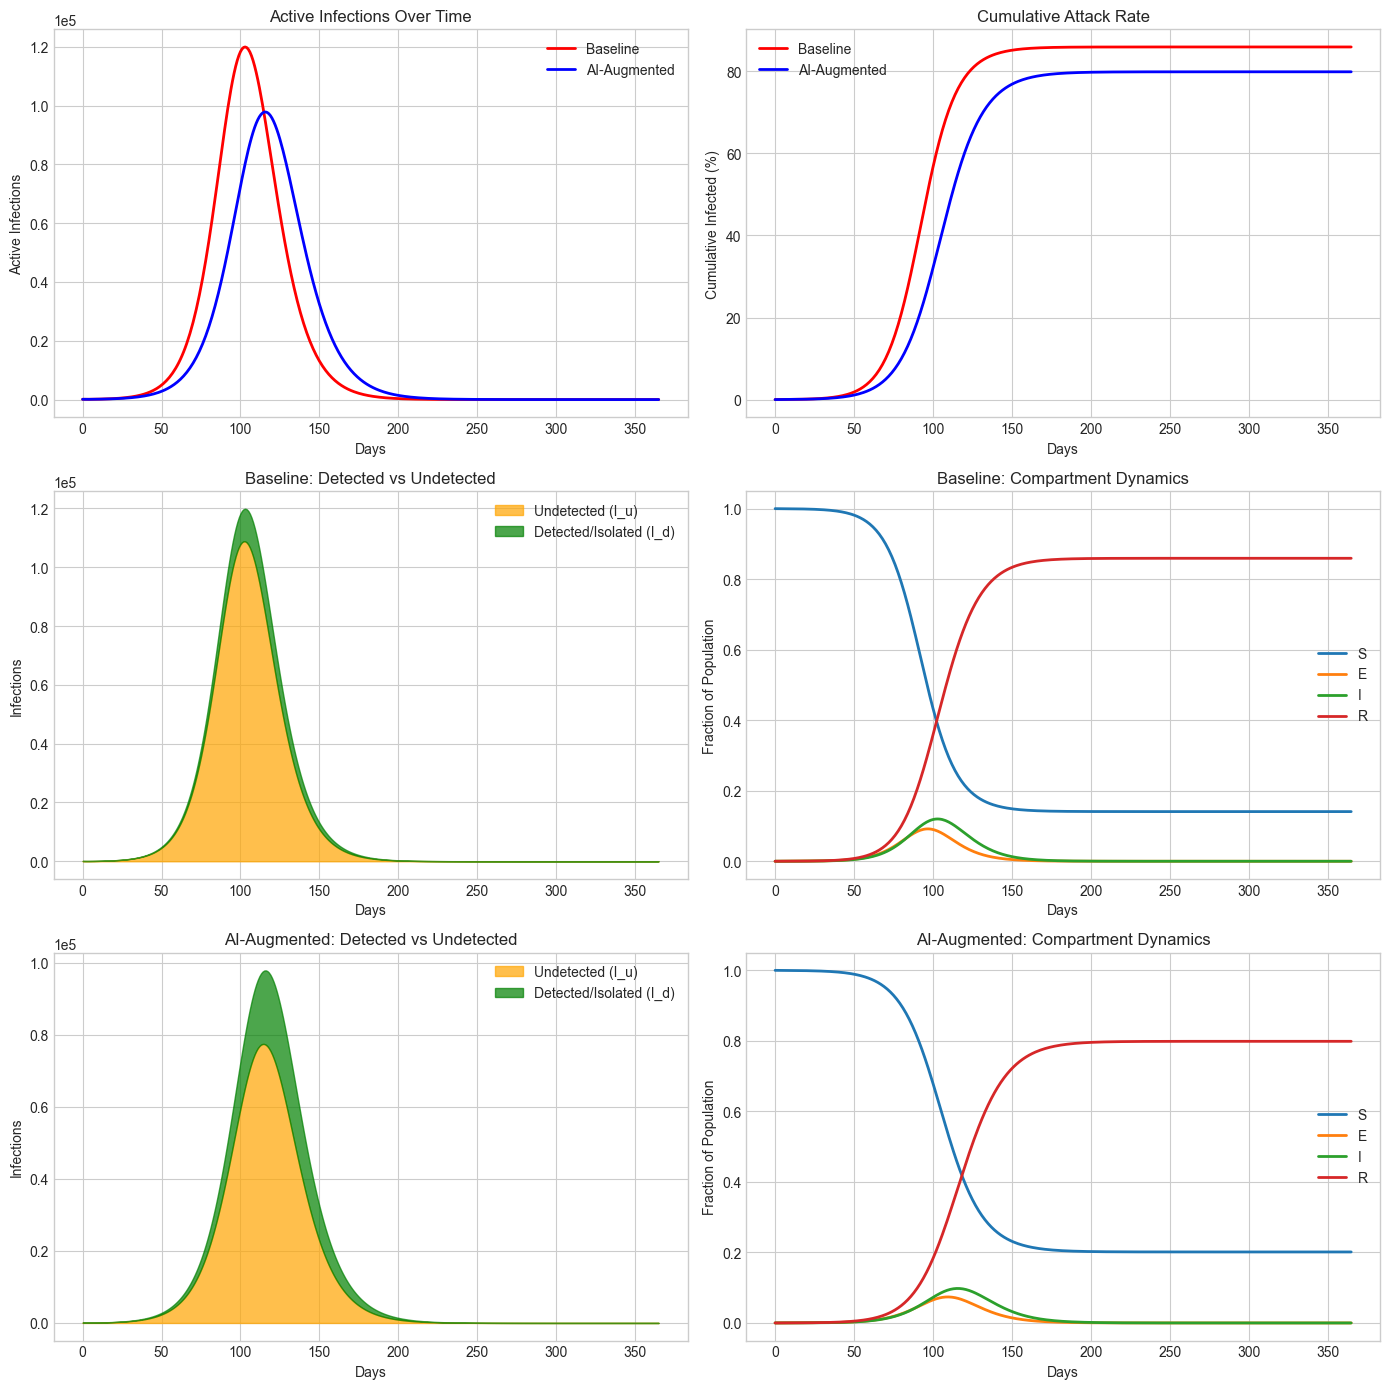

In [ ]:
def plot_comparison(results_baseline, results_ai, population):
    """Plot comparison of baseline vs AI-augmented intervention."""
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    
    t = results_baseline['t']
    
    # Row 1: Comparison plots
    # Plot 1: Active infections
    ax = axes[0, 0]
    ax.plot(t, results_baseline['I_total'], 'r-', label='Baseline', linewidth=2)
    ax.plot(t, results_ai['I_total'], 'b-', label='AI-Augmented', linewidth=2)
    ax.set_xlabel('Days')
    ax.set_ylabel('Active Infections')
    ax.set_title('Active Infections Over Time')
    ax.legend()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    # Plot 2: Cumulative infections
    ax = axes[0, 1]
    ax.plot(t, results_baseline['cumulative_infected'] / population * 100, 'r-', 
            label='Baseline', linewidth=2)
    ax.plot(t, results_ai['cumulative_infected'] / population * 100, 'b-', 
            label='AI-Augmented', linewidth=2)
    ax.set_xlabel('Days')
    ax.set_ylabel('Cumulative Infected (%)')
    ax.set_title('Cumulative Attack Rate')
    ax.legend()
    
    # Row 2: Baseline details
    # Plot 3: Detected vs Undetected (Baseline)
    ax = axes[1, 0]
    ax.fill_between(t, 0, results_baseline['I_u'], alpha=0.7, label='Undetected (I_u)', color='orange')
    ax.fill_between(t, results_baseline['I_u'], results_baseline['I_total'], alpha=0.7, 
                    label='Detected/Isolated (I_d)', color='green')
    ax.set_xlabel('Days')
    ax.set_ylabel('Infections')
    ax.set_title('Baseline: Detected vs Undetected')
    ax.legend()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    # Plot 4: All compartments (Baseline)
    ax = axes[1, 1]
    ax.plot(t, results_baseline['S'] / population, label='S', linewidth=2)
    ax.plot(t, results_baseline['E'] / population, label='E', linewidth=2)
    ax.plot(t, results_baseline['I_total'] / population, label='I', linewidth=2)
    ax.plot(t, results_baseline['R'] / population, label='R', linewidth=2)
    ax.set_xlabel('Days')
    ax.set_ylabel('Fraction of Population')
    ax.set_title('Baseline: Compartment Dynamics')
    ax.legend()
    
    # Row 3: AI-Augmented details
    # Plot 5: Detected vs Undetected (AI scenario)
    ax = axes[2, 0]
    ax.fill_between(t, 0, results_ai['I_u'], alpha=0.7, label='Undetected (I_u)', color='orange')
    ax.fill_between(t, results_ai['I_u'], results_ai['I_total'], alpha=0.7, 
                    label='Detected/Isolated (I_d)', color='green')
    ax.set_xlabel('Days')
    ax.set_ylabel('Infections')
    ax.set_title('AI-Augmented: Detected vs Undetected')
    ax.legend()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    # Plot 6: All compartments (AI scenario)
    ax = axes[2, 1]
    ax.plot(t, results_ai['S'] / population, label='S', linewidth=2)
    ax.plot(t, results_ai['E'] / population, label='E', linewidth=2)
    ax.plot(t, results_ai['I_total'] / population, label='I', linewidth=2)
    ax.plot(t, results_ai['R'] / population, label='R', linewidth=2)
    ax.set_xlabel('Days')
    ax.set_ylabel('Fraction of Population')
    ax.set_title('AI-Augmented: Compartment Dynamics')
    ax.legend()
    
    plt.tight_layout()
    return fig

fig = plot_comparison(results_baseline, results_ai, CITY_POPULATION)
plt.show()

In [ ]:
def compute_metrics(results, population):
    """Compute key epidemic metrics."""
    return {
        'peak_infections': results['I_total'].max(),
        'peak_day': results['t'][results['I_total'].argmax()],
        'total_infected': results['cumulative_infected'][-1],
        'attack_rate': results['cumulative_infected'][-1] / population * 100,
        'peak_pct': results['I_total'].max() / population * 100
    }

metrics_baseline = compute_metrics(results_baseline, CITY_POPULATION)
metrics_ai = compute_metrics(results_ai, CITY_POPULATION)

print("\nEpidemic Metrics Comparison:")
print(f"{'Metric':<25} {'Baseline':>15} {'AI-Augmented':>15} {'Reduction':>12}")
print("-" * 70)
print(f"{'Peak infections':<25} {metrics_baseline['peak_infections']:>15,.0f} {metrics_ai['peak_infections']:>15,.0f} {(1 - metrics_ai['peak_infections']/metrics_baseline['peak_infections'])*100:>11.1f}%")
print(f"{'Peak day':<25} {metrics_baseline['peak_day']:>15.0f} {metrics_ai['peak_day']:>15.0f} {'—':>12}")
print(f"{'Total infected':<25} {metrics_baseline['total_infected']:>15,.0f} {metrics_ai['total_infected']:>15,.0f} {(1 - metrics_ai['total_infected']/metrics_baseline['total_infected'])*100:>11.1f}%")
print(f"{'Attack rate (%)':<25} {metrics_baseline['attack_rate']:>15.1f} {metrics_ai['attack_rate']:>15.1f} {'—':>12}")


Epidemic Metrics Comparison:
Metric                           Baseline    AI-Augmented    Reduction
----------------------------------------------------------------------
Peak infections                   119,938          97,823        18.4%
Peak day                              103             116            —
Total infected                    859,174         798,661         7.0%
Attack rate (%)                      85.9            79.9            —


## Parameter Sensitivity Analysis

Explore how each AI intervention parameter affects outcomes.

In [ ]:
def sensitivity_analysis(param_name: str, param_range: np.ndarray, base_intervention: AIInterventionParams):
    """Run sensitivity analysis on a single parameter."""
    results = []
    
    for val in param_range:
        # Create modified intervention
        intervention = AIInterventionParams(
            epsilon_ct=base_intervention.epsilon_ct,
            rho_sx=base_intervention.rho_sx,
            tau_contact=base_intervention.tau_contact,
            tau_care=base_intervention.tau_care,
            c_q=base_intervention.c_q
        )
        setattr(intervention, param_name, val)
        
        # Run simulation
        model = SEIRModel(CITY_POPULATION, disease, intervention)
        sim = model.simulate(days=365, initial_infected=100)
        
        results.append({
            'param_value': val,
            'peak': sim['I_total'].max(),
            'total': sim['cumulative_infected'][-1]
        })
    
    return results

# Sensitivity on key parameters
params_to_test = {
    'epsilon_ct': ('Contact Tracing Efficacy', np.linspace(0.1, 0.95, 20)),
    'c_q': ('Quarantine Compliance', np.linspace(0.2, 0.95, 20)),
    'tau_contact': ('Contact Notification Delay (days)', np.linspace(0.1, 5.0, 20)),
    'rho_sx': ('Symptom Reporting Rate', np.linspace(0.1, 0.9, 20))
}

sensitivity_results = {}
for param, (label, range_vals) in params_to_test.items():
    sensitivity_results[param] = sensitivity_analysis(param, range_vals, BASELINE_INTERVENTION)

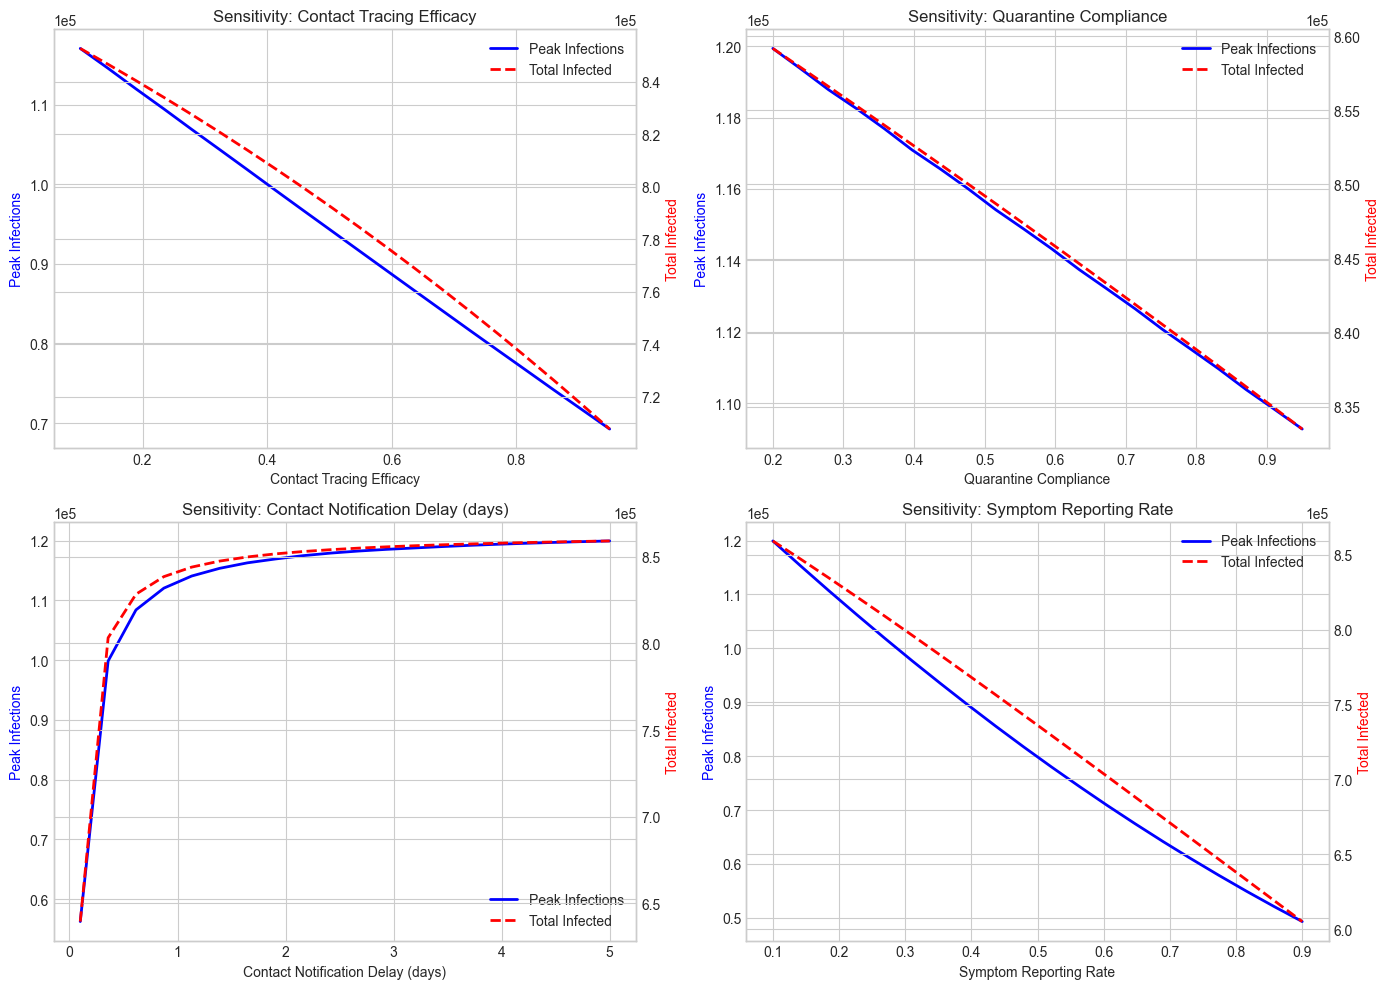

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (param, (label, range_vals)) in zip(axes.flat, params_to_test.items()):
    results = sensitivity_results[param]
    x = [r['param_value'] for r in results]
    y_peak = [r['peak'] for r in results]
    y_total = [r['total'] for r in results]
    
    ax2 = ax.twinx()
    
    l1, = ax.plot(x, y_peak, 'b-', linewidth=2, label='Peak Infections')
    l2, = ax2.plot(x, y_total, 'r--', linewidth=2, label='Total Infected')
    
    ax.set_xlabel(label)
    ax.set_ylabel('Peak Infections', color='b')
    ax2.set_ylabel('Total Infected', color='r')
    ax.set_title(f'Sensitivity: {label}')
    
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    lines = [l1, l2]
    ax.legend(lines, [l.get_label() for l in lines], loc='best')

plt.tight_layout()
plt.show()

## Interactive Parameter Exploration

Adjust AI intervention parameters and see real-time impact.

In [ ]:
def run_scenario(
    epsilon_ct: float = 0.05,
    rho_sx: float = 0.10,
    tau_contact: float = 5.0,
    tau_care: float = 7.0,
    c_q: float = 0.20,
    R0: float = 2.5
):
    """Run a scenario with custom parameters and display results."""
    
    disease = DiseaseParams(R0=R0, incubation_days=5.0, infectious_days=7.0)
    intervention = AIInterventionParams(
        epsilon_ct=epsilon_ct,
        rho_sx=rho_sx,
        tau_contact=tau_contact,
        tau_care=tau_care,
        c_q=c_q
    )
    
    model = SEIRModel(CITY_POPULATION, disease, intervention)
    results = model.simulate(days=365, initial_infected=100)
    
    # Compute metrics
    peak = results['I_total'].max()
    peak_day = results['t'][results['I_total'].argmax()]
    total = results['cumulative_infected'][-1]
    
    # Effective R
    R_eff_initial = model.compute_R_effective(CITY_POPULATION)
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(results['t'], results['I_total'], 'r-', linewidth=2)
    ax1.axhline(y=peak, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=peak_day, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Days')
    ax1.set_ylabel('Active Infections')
    ax1.set_title(f'Peak: {peak:,.0f} on day {peak_day:.0f}')
    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    ax2.stackplot(results['t'], 
                  results['S']/CITY_POPULATION,
                  results['E']/CITY_POPULATION,
                  results['I_total']/CITY_POPULATION,
                  results['R']/CITY_POPULATION,
                  labels=['S', 'E', 'I', 'R'],
                  alpha=0.8)
    ax2.set_xlabel('Days')
    ax2.set_ylabel('Fraction of Population')
    ax2.set_title(f'Attack Rate: {total/CITY_POPULATION*100:.1f}% | R_eff(t=0): {R_eff_initial:.2f}')
    ax2.legend(loc='right')
    
    plt.tight_layout()
    plt.show()
    
    return results

# Example: Moderate AI intervention (should show pandemic with reduced peak)
_ = run_scenario(epsilon_ct=0.12, rho_sx=0.18, tau_contact=4.0, tau_care=5.5, c_q=0.28)

---

## Next: Multi-City Model

The next notebook will extend this to a network of cities with:
- Inter-city transmission (travel/commuting)
- Heterogeneous intervention deployment
- Supply chain constraints on intervention capacity